In [67]:
# import library
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [107]:
# load dataset with tf.keras
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
# print shape
print(train_images.shape,train_labels.shape, test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


index : 0
label :  5
image


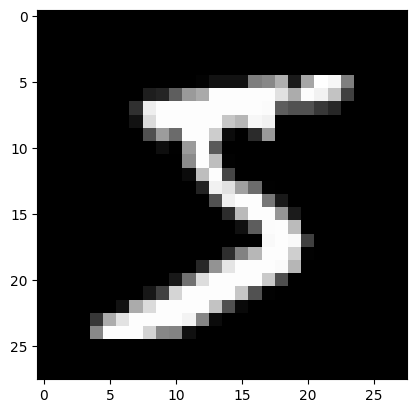

In [108]:
# check image
i = 0
print("index : " + str(i))
print("label : ", train_labels[i])
print("image")    
plt.imshow(train_images[i], cmap='gray')
plt.show()

In [109]:
# normalization
train_images = train_images/255.0
test_images = test_images/255.0

In [112]:
# input shape
input_shape=(28,28,1)

In [113]:
config = [16, 16, 'M','Cl']

In [ ]:
# VGG 13 Cl dense 4096,4096,1000
config = [64, 64, 'M', 128 ,128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'Cl']

In [70]:
def make_layers(config,dense=4096, num_class=10):
    layers = []
    for v in config:
        if v == 'M':
            layers += [tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=None,padding='same')]
        elif v == 'Cl':
            layers += [tf.keras.layers.Flatten()]
            layers += [tf.keras.layers.Dense(dense, activation='relu')]
            layers += [tf.keras.layers.Dense(dense, activation='relu')]
            layers += [tf.keras.layers.Dense(num_class,activation=tf.keras.activations.softmax)]    
        else:
            layers += [tf.keras.layers.Conv2D(v,kernel_size=(3,3),strides=(1, 1),padding='same')]
            layers += [tf.keras.layers.BatchNormalization()]
            layers += [tf.keras.layers.ReLU()]
    return tf.keras.models.Sequential(layers)

In [74]:
def make_layers(config,dense=4096,num_class=10):
    layers = []
    for v in config:
        if v == 'M':
            layers += [tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=None,padding='same')]
        elif v == 'Cl':
            layers += [
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(dense, activation='relu'),
            tf.keras.layers.Dense(dense, activation='relu'),
            tf.keras.layers.Dense(num_class,activation=tf.keras.activations.softmax)
            ]
        else:
            layers += [tf.keras.layers.Conv2D(v,kernel_size=(3,3),strides=(1, 1),padding='same'),
                       tf.keras.layers.BatchNormalization(),
                       tf.keras.layers.ReLU()
            ]
    return tf.keras.models.Sequential(layers)

In [100]:
def make_classification_layers(dense = 4096, num_classes=10):
    classification_layers = tf.keras.models.Sequential([
                            tf.keras.layers.Flatten(),
                            tf.keras.layers.Dense(dense, activation='relu'),
                            tf.keras.layers.Dense(dense, activation='relu'),
                            tf.keras.layers.Dense(num_classes,activation=tf.keras.activations.softmax)
                            ],name='classification_layers')
    return classification_layers

In [101]:
def make_cbr_layers(v):
    cbr_layers = tf.keras.models.Sequential([
                            tf.keras.layers.Conv2D(v,kernel_size=(3,3),strides=(1, 1),padding='same'),
                            tf.keras.layers.BatchNormalization(),
                            tf.keras.layers.ReLU()
                            ])
    return cbr_layers

In [114]:
def make_layers(config,dense =4096, num_class=10):
    layers = []
    for v in config:
        if v == 'M':
            layers += [tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=None,padding='same')]
        elif v == 'Cl':
            layers += [make_classification_layers(dense,num_class)]
        else:
            layers += [make_cbr_layers(v)]
    return tf.keras.models.Sequential(layers)

In [121]:
# create model
model = make_layers(config,dense =100, num_class=10)

Model: "model_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 28, 28, 1)]       0         
                                                                 
 sequential_53 (Sequential)  (None, 28, 28, 16)        224       
                                                                 
 sequential_54 (Sequential)  (None, 28, 28, 16)        2384      
                                                                 
 max_pooling2d_26 (MaxPooli  (None, 14, 14, 16)        0         
 ng2D)                                                           
                                                                 
 classification_layers (Seq  (None, 10)                324810    
 uential)                                                        
                                                                 
Total params: 327418 (1.25 MB)
Trainable params: 327354 (1

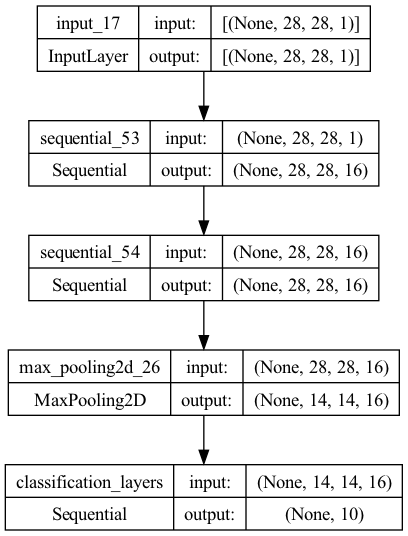

In [122]:
def get_functional_model(model):
  x = tf.keras.layers.Input(shape=(input_shape))
  model = tf.keras.Model(inputs=[x],outputs=model.call(x))
  return model

functional_model = get_functional_model(model)

functional_model.summary()
with open("model_summary.txt", "w") as fp:
    functional_model.summary(print_fn=lambda x: fp.write(x + "\r\n"))

tf.keras.utils.plot_model(functional_model, show_shapes=True, show_layer_names=True, to_file='model.png')
from IPython.display import Image
Image(retina=False, filename='model.png')

In [123]:
# define loss
loss = tf.keras.losses.SparseCategoricalCrossentropy()
# define optimizer
optimizer = tf.keras.optimizers.Adam()

In [124]:
# compile model
model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])

In [125]:
# training
history = model.fit(train_images, train_labels,epochs=3)

Epoch 1/3
1875/1875 [==============================] - 103s 54ms/step - loss: 0.1321 - accuracy: 0.9589
Epoch 2/3
1875/1875 [==============================] - 97s 52ms/step - loss: 0.0520 - accuracy: 0.9838
Epoch 3/3
  40/1875 [..............................] - ETA: 1:32 - loss: 0.0403 - accuracy: 0.9867

In [ ]:
# save model
model.save('my_model')

In [ ]:
# load model
model = tf.keras.models.load_model('my_model')

In [ ]:
# reset model
tf.keras.backend.clear_session()
del model

In [ ]:
# prediction
predictions = model(test_images)

In [ ]:
# check test label and prediction
i = 0
print("index : " + str(i))
print("label : ", test_labels[i])
print("predictions : ", np.argmax(predictions[i]))
print("image")    
plt.imshow(test_images[i], cmap='gray')
plt.show()